In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import torch

from keras.datasets import cifar10
from tqdm.notebook import tqdm


In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print (x_train.shape, y_train.shape)
print (x_test.shape, y_test.shape)

(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)


In [3]:
def relu(z):
    """
    Apply the ReLU (Rectified Linear Unit) activation function.

    Parameters:
    z (numpy.ndarray): Input array.

    Returns:
    numpy.ndarray: Output array where each element is the maximum of 0 and the corresponding input element.
    """
    return np.maximum(0, z)

def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

def softmax(X):
    """
    Apply the softmax function to convert logits to probabilities.

    Parameters:
    X (numpy.ndarray): Input array of shape (n_samples, n_classes).

    Returns:
    numpy.ndarray: Output array of the same shape as input, where each row represents a probability distribution.
    """
    X_stable = X - np.max(X, axis=1, keepdims=True)
    s = np.exp(X_stable)
    total = np.sum(s, axis=1).reshape(-1, 1)
    return s / total

In [14]:
from regex import F
from scipy.signal import correlate2d

class CNN:
    def __init__(self, image_shape=(32, 32, 3), filter_shape=(3, 3, 3), num_filters=16, num_classes=10, l2_lambda=0.0):
        self.num_filters = num_filters
        self.filter_shape = filter_shape
        self.l2_lambda = l2_lambda

        self.image_shape = image_shape
        self.num_image_channels = image_shape[2]
        self.num_classes = num_classes
    
        self.width_out = self.image_shape[0] - self.filter_shape[0] + 1
        self.height_out = self.image_shape[1] - self.filter_shape[1] + 1
        self.filter_weights = \
            np.random.randn(self.num_filters, *self.filter_shape) *\
                np.sqrt(2 / (np.prod(self.filter_shape)))
        self.filter_bias = np.zeros((self.num_filters, 1))
        
        # Linear layer shape
        self.linear_weights = \
            np.random.randn(self.num_filters * self.width_out * self.height_out, num_classes) *\
                np.sqrt(2 / (self.num_filters * self.width_out * self.height_out))
        self.linear_bias = np.zeros(num_classes)

        self.cache = {}
        self.grad_history = {}
        self.weights_history = {}
        # Gradients
        self.adam_cache = {}
        for name in ['linear_weights', 'linear_bias', 'filter_weights', 'filter_bias']:
            self.adam_cache[name] = {
                'm': np.zeros_like(getattr(self, name)),
                'v': np.zeros_like(getattr(self, name))
            }
        self.t = 1  # timestep


    def convolve_layer(self, input):
        N, H, W, C = input.shape
        F, KH, KW, _ = self.filter_weights.shape
        H_out = H - KH + 1
        W_out = W - KW + 1

        patches = np.lib.stride_tricks.sliding_window_view(input, (KH, KW), axis=(1, 2))
        patches = patches.reshape(N, H_out, W_out, -1)
        filters = self.filter_weights.reshape(F, -1)

        conv_out = np.einsum('nhwc,fc->nfhw', patches, filters)
        conv_out += self.filter_bias.reshape(1, F, 1, 1)

        self.cache['convolve_input'] = input
        self.cache['relu_input'] = conv_out.copy()
        return np.where(conv_out > 0, conv_out, 0.01 * conv_out)
    
    def linear_layer(self, input):
        output = input @ self.linear_weights + self.linear_bias
        self.cache['linear_input'] = input
        return output

    def softmax_layer(self, input):
        output = softmax(input)
        self.cache['softmax_input'] = input
        self.cache['softmax_output'] = output
        return output
    
    def forward(self, x, y):
        conv_out = self.convolve_layer(x)
        linear_input = conv_out.reshape(x.shape[0], -1)
        logits = self.linear_layer(linear_input)
        probs = self.softmax_layer(logits)

        loss = np.mean(-np.log(probs[np.arange(x.shape[0]), y.flatten()] + 1e-10))
        l2_loss = 0.5 * self.l2_lambda * (
            np.sum(self.linear_weights ** 2) + np.sum(self.filter_weights ** 2)
        )
        loss += l2_loss
        acc = np.mean(np.argmax(probs, axis=1) == y.flatten()) * 100
        return probs, acc, loss

    def backward(self, y):
        y_onehot = (y[:, np.newaxis] == np.arange(self.num_classes)).astype(np.float32)
        dL_softmax = self.cache['softmax_output'] - y_onehot
        
        # print(f"dL_softmax shape: {dL_softmax.shape}")

        dL_linear_weights = self.cache['linear_input'].T @ dL_softmax + \
            self.l2_lambda * self.linear_weights
        dL_linear_bias = np.mean(dL_softmax, axis=0)
        
        # print(f"dL_linear_weights shape: {dL_linear_weights.shape}")
        # print(f"dL_linear_bias shape: {dL_linear_bias.shape}")

        batch_size = y.shape[0]
        dL_conv_flat = dL_softmax @ self.linear_weights.T
        
        # print(f"dL_conv_flat shape: {dL_conv_flat.shape}")
        dL_conv_out = dL_conv_flat.reshape(self.cache['relu_input'].shape) \
            * np.where(self.cache['relu_input'] > 0, 1, 0.01)

        # print(f"dL_conv_out shape: {dL_conv_out.shape}")
        
        dL_filter_weights = np.zeros_like(self.filter_weights)
        dL_filter_bias = np.zeros_like(self.filter_bias)

        # print(f"dL_filter_weights shape: {dL_filter_weights.shape}")
        # print(f"dL_filter_bias shape: {dL_filter_bias.shape}")
        
        for i in range(batch_size):
            for j in range(self.num_filters):
                for c in range(self.num_image_channels):
                    dL_filter_weights[j, :, :, c] += correlate2d(
                        self.cache['convolve_input'][i, :, :, c], dL_conv_out[i, j], mode='valid')
                dL_filter_bias[j] += np.sum(dL_conv_out[i, j])
                
        dL_filter_weights += self.l2_lambda * self.filter_weights

        grads = {
            'linear_weights': dL_linear_weights / batch_size,
            'linear_bias': dL_linear_bias,
            'filter_weights': dL_filter_weights / batch_size,
            'filter_bias': dL_filter_bias / batch_size,
        }
        self.grads = grads
        self.update_grads(grads)

    def update(self, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        for name in self.grads:
            grad = self.grads[name]
            m, v = self.adam_cache[name]['m'], self.adam_cache[name]['v']

            m[:] = beta1 * m + (1 - beta1) * grad
            v[:] = beta2 * v + (1 - beta2) * (grad ** 2)

            m_hat = m / (1 - beta1 ** self.t)
            v_hat = v / (1 - beta2 ** self.t)

            getattr(self, name)[:] -= lr * m_hat / (np.sqrt(v_hat) + eps)
        self.t += 1     

    
    def update_grads(self, grads):
        if not self.grad_history or not self.weights_history:
            self.grad_history = {}
            self.weights_history = {}
        for key in grads:
            if key not in self.grad_history:
                self.grad_history[key] = []
                self.weights_history[key] = []
            self.weights_history[key].append(
                np.linalg.norm(getattr(self, key))
            )
            self.grad_history[key].append(
                np.linalg.norm(grads[key])
            )

        self.grads = grads
        
    
    def train(self, x_train, y_train, epochs=10, batch_size=64, lr=0.001):
        y_train = y_train.flatten()
        accuracies = []
        losses = []
        for epoch in tqdm(range(epochs), desc="Epochs"):
            indices = np.arange(x_train.shape[0])
            np.random.shuffle(indices)
            x_train, y_train = x_train[indices], y_train[indices]

            epoch_loss, epoch_acc, count = 0, 0, 0
            for i in tqdm(range(0, x_train.shape[0], batch_size), leave=False, desc=f"Batches in Epoch {epoch+1}"):
                xb = x_train[i:i+batch_size]
                yb = y_train[i:i+batch_size]

                probs, acc, loss = self.forward(xb, yb)
                self.backward(yb)
                self.update(lr)

                epoch_loss += loss
                epoch_acc += acc
                count += 1

            accuracies.append(epoch_acc/count)
            losses.append(epoch_loss/count)
            print(f"Epoch {epoch+1}: Accuracy={epoch_acc/count:.2f}% | Loss={epoch_loss/count:.4f}")

        
        plt.figure(figsize=(10, 6))
        plt.plot(accuracies, label='Accuracy', color='blue')
        plt.plot(losses, label='Loss', color='red')
        plt.xlabel('Epoch')
        plt.ylabel('Value')
        plt.title('Training Accuracy and Loss')
        plt.legend()
        plt.grid(True)
        plt.show()
        
        for key in self.weights_history:
            plt.figure(figsize=(10, 6))
            plt.plot(self.weights_history[key], label=f'{key} Weights Norm', color='blue')
            plt.plot(self.grad_history[key], label=f'{key} Gradients Norm', color='red')
            plt.xlabel('Epoch')
            plt.ylabel('Norm Value')
            plt.title(f'Norm of Weights and Gradients for {key}')
            plt.legend()
            plt.grid(True)
            plt.show()
       
    def predict(self, x_test):
        conv_out = self.convolve_layer(x_test)
        linear_input = conv_out.reshape(x_test.shape[0], -1)
        logits = self.linear_layer(linear_input)
        probs = self.softmax_layer(logits)
        return np.argmax(probs, axis=1)


In [13]:
model = CNN()

Epochs:   0%|          | 0/15 [00:00<?, ?it/s]

Batches in Epoch 1:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 1: Accuracy=26.56% | Loss=10.0040


Batches in Epoch 2:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 2: Accuracy=32.84% | Loss=6.7407


...

Epoch 13: Accuracy=34.60% | Loss=12.9735


Batches in Epoch 14:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 14: Accuracy=33.33% | Loss=13.4098


Batches in Epoch 15:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 15: Accuracy=33.93% | Loss=13.4209


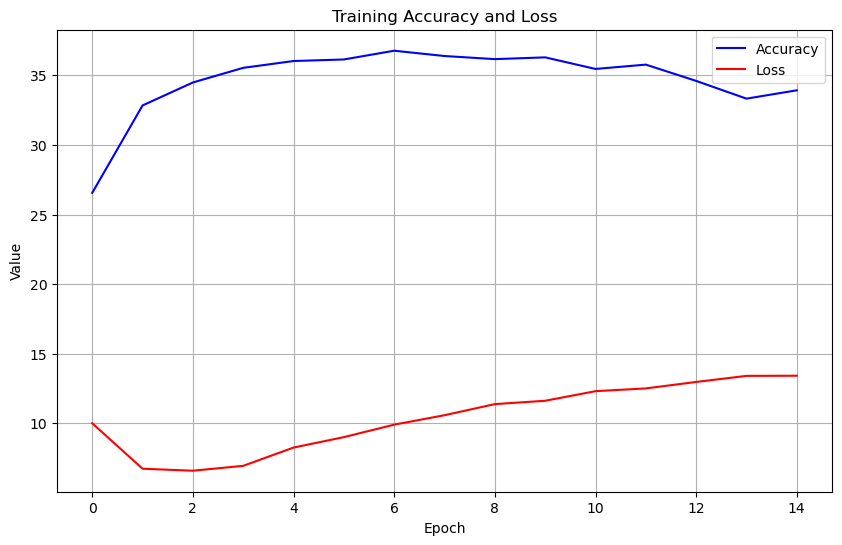

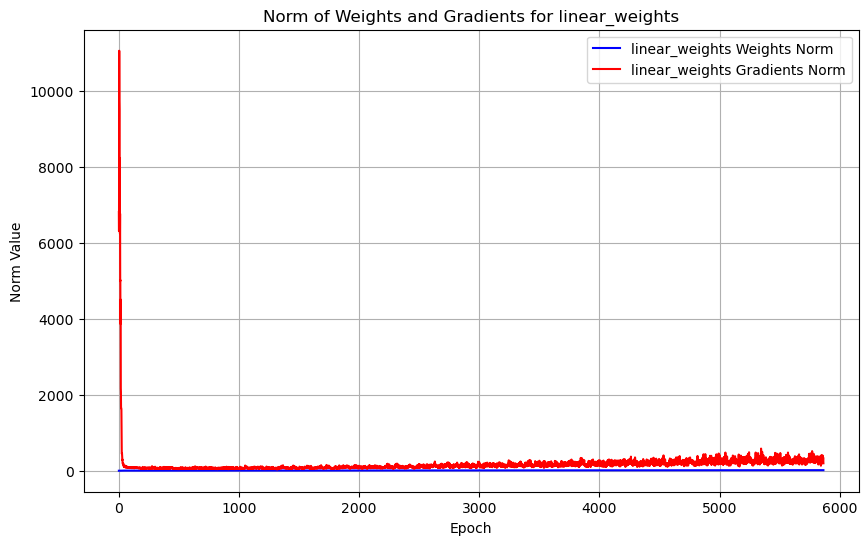

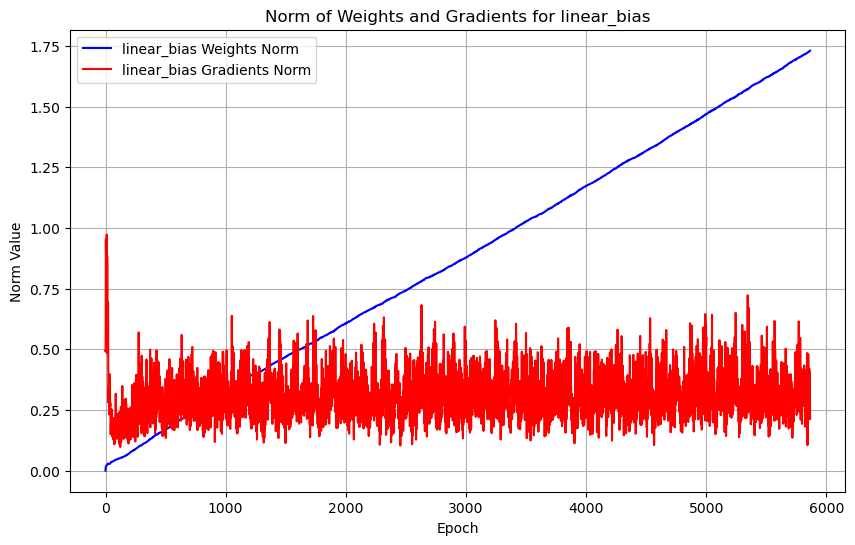

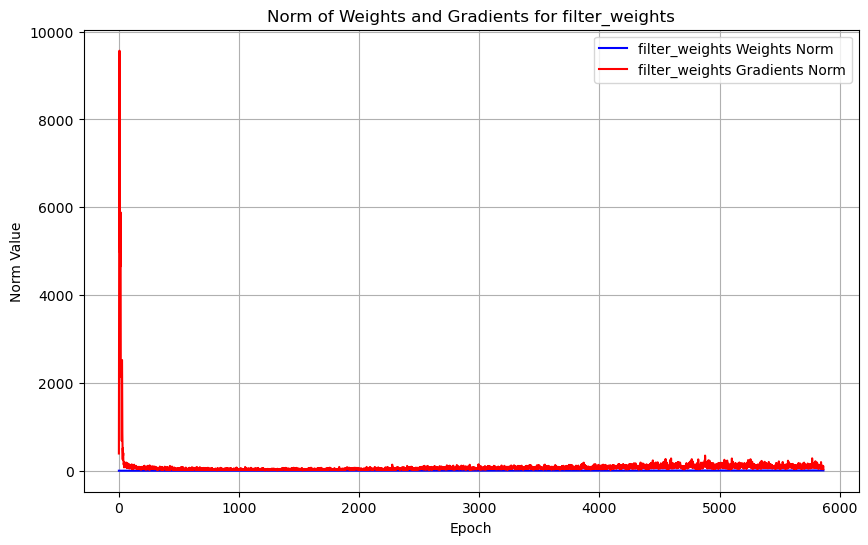

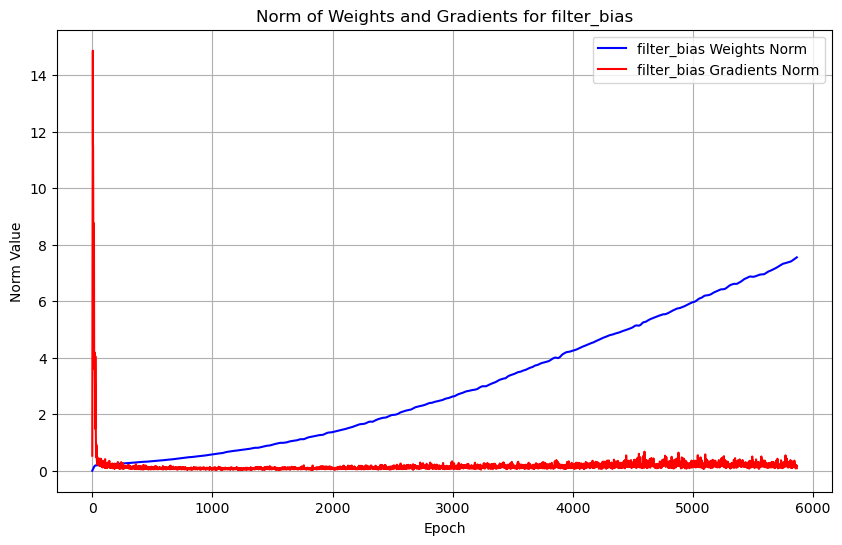

In [9]:
X = x_train[:50000]
y = y_train[:50000]
model.train(X, y, epochs=15, batch_size=128, lr=0.003)

Test Accuracy: 25.95%
Test Loss: 15.5520


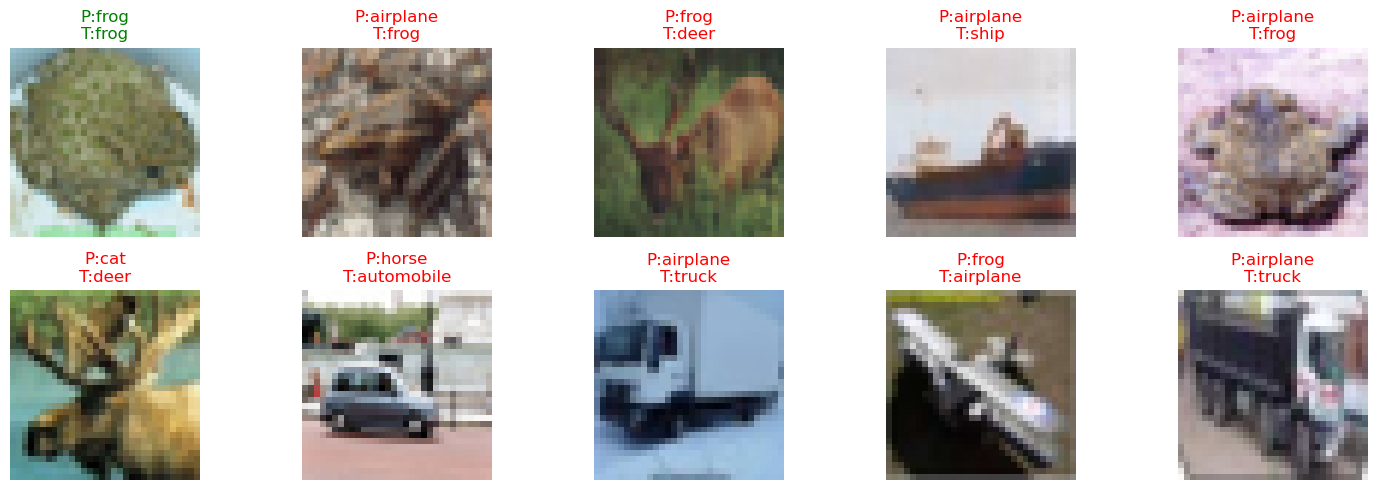

In [11]:
import matplotlib.pyplot as plt

def evaluate_and_visualize(model, x_test, y_test, class_names, sample_count=10):
    # Evaluate full test accuracy/loss
    probs, acc, loss = model.forward(x_test, y_test)
    print(f"Test Accuracy: {acc:.2f}%")
    print(f"Test Loss: {loss:.4f}")

    # Predict classes for a few samples
    indices = np.random.choice(x_test.shape[0], sample_count, replace=False)
    x_sample = x_test[indices]
    y_sample = y_test[indices].flatten()
    preds = np.argmax(model.forward(x_sample, y_sample)[0], axis=1)

    # Plot predictions
    plt.figure(figsize=(15, 5))
    for i in range(sample_count):
        plt.subplot(2, sample_count // 2, i + 1)
        plt.imshow(x_sample[i])
        plt.axis('off')
        color = 'green' if preds[i] == y_sample[i] else 'red'
        plt.title(f"P:{class_names[preds[i]]}\nT:{class_names[y_sample[i]]}", color=color)
    plt.tight_layout()
    plt.show()
    
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
evaluate_and_visualize(model, x_test, y_test, class_names)